# 04 · Modelos PD y estrategia Champion/Challenger — Caso 15 · Caja Rural 360

**Alcance:** sección **6.6**. Narrativa en `reports/06_modelos_pd.md`.

**Reglas que se respetan aquí**

1. Todos los candidatos usan la misma población, la misma partición temporal y el mismo preprocesamiento (el pipeline de 6.3 ajustado solo con DEV): la comparación mide el algoritmo, no el tratamiento de datos.
2. El **tuning se hace con validación temporal dentro de DEV** (entrenar 2021 y validar 2022; entrenar 2021-2022 y validar 2023). VAL solo compara modelos ya entrenados y el OOT no se toca: se abre una sola vez en 6.7.
3. **Mismo veto de fairness para todos.** Si una variable no puede usarse en el scorecard por ser proxy de territorio, ruralidad, informalidad, edad u hogar (6.5), tampoco puede entrar por la puerta de atrás en un modelo de árboles. Se mide aparte cuánto se "gana" al levantarlo.
4. Grillas chicas y con racional: profundidad baja, mínimo de casos por hoja y regularización. Con 351 defaults en DEV, una búsqueda masiva encuentra ruido.

| Sección | Contenido |
|---|---|
| 1 | Candidatos, espacio de variables y grillas |
| 2 | Tuning con validación temporal dentro de DEV |
| 3 | Comparación integral: discriminación, calibración, estabilidad y costo operativo |
| 4 | Regla de selección Champion / Challenger |
| 5 | ¿Cuánto costaría levantar el veto de fairness? |
| 6 | Artefactos y trazabilidad |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
import joblib
raw = data.load_raw()
pop, _ = data.pd_population(raw)
fx = features.build_features(pop)
T = cfg.TARGET
dev, val, oot = (fx[fx["sample"] == s].copy() for s in cfg.SAMPLE_ORDER)
cols_in = pipeline.pipeline_input_columns()
pipe = pipeline.build_pipeline().fit(dev[cols_in])
card = sc.Scorecard.load(cfg.ROOT / "models" / "scorecard_pd_v1.json")
(cfg.ROOT / "models").mkdir(exist_ok=True)

X_dev = pipe.transform(dev[cols_in])
vetadas = models.columnas_vetadas(list(X_dev.columns))
print(f"Matriz del pipeline: {X_dev.shape[1]} columnas | vetadas por fairness: {len(vetadas)} -> {vetadas}")
print(f"Espacio de variables de los challengers: {X_dev.shape[1] - len(vetadas)} columnas")
print(f"Champion candidato (scorecard 6.5): {card.variables}")
print("Grillas:", {k: v for k, v in models.GRIDS.items()})

Matriz del pipeline: 32 columnas | vetadas por fairness: 9 -> ['age', 'distance_to_branch_km', 'household_dependents', 'cash_income_share', 'region_Centro', 'region_Lima', 'region_Norte', 'region_Oriente', 'region_Sur']
Espacio de variables de los challengers: 23 columnas
Champion candidato (scorecard 6.5): ['bureau_score', 'dti_post', 'ahorro_sobre_monto']
Grillas: {'Regresión logística (pipeline completo)': {'C': [0.05, 0.25, 1.0]}, 'Random Forest': {'max_depth': [4, 6], 'min_samples_leaf': [20, 50], 'max_features': ['sqrt', 0.5]}, 'XGBoost': {'max_depth': [2, 3], 'n_estimators': [200, 400], 'min_child_weight': [20, 50]}, 'LightGBM': {'num_leaves': [7, 15], 'n_estimators': [200, 400], 'min_child_samples': [30, 60]}}


## 2. Tuning con validación temporal dentro de DEV

In [3]:
candidatos, tuning = models.train_candidates(dev, pipe, card, card.binnings, excluir_sensibles=True)
for nombre, tabla in tuning.items():
    print(f"\n{nombre} · mejor configuración por Gini medio fuera del fold")
    display(tabla.head(4))
    tabla.to_csv(cfg.TABLES / f"modelos_tuning_{cfg.slug(nombre.split()[0])}.csv", index=False)
print({n: c_.params for n, c_ in candidatos.items()})


Regresión logística (pipeline completo) · mejor configuración por Gini medio fuera del fold


,C,gini_fold_1,gini_fold_2,gini_cv
0,0.0500,0.3777,0.3986,0.3882
1,0.2500,0.3853,0.3903,0.3878
2,1.0000,0.3857,0.3853,0.3855



Random Forest · mejor configuración por Gini medio fuera del fold


,max_depth,min_samples_leaf,max_features,gini_fold_1,gini_fold_2,gini_cv
0,4,50,0.5000,0.3534,0.4065,0.3799
1,6,50,0.5000,0.3491,0.4043,0.3767
2,4,20,0.5000,0.3511,0.3973,0.3742
3,6,20,0.5000,0.3423,0.3871,0.3647



XGBoost · mejor configuración por Gini medio fuera del fold


,max_depth,n_estimators,min_child_weight,gini_fold_1,gini_fold_2,gini_cv
0,2,200,50,0.3448,0.4049,0.3748
1,3,200,50,0.3448,0.4047,0.3748
2,2,400,50,0.3448,0.4006,0.3727
3,3,400,50,0.3448,0.3995,0.3722



LightGBM · mejor configuración por Gini medio fuera del fold


,num_leaves,n_estimators,min_child_samples,gini_fold_1,gini_fold_2,gini_cv
0,7,200,60,0.3192,0.3516,0.3354
1,7,200,30,0.3034,0.3548,0.3291
2,15,200,60,0.2991,0.3119,0.3055
3,7,400,30,0.2605,0.3240,0.2923


{'Scorecard WOE (6.5)': {'variables': ['bureau_score', 'dti_post', 'ahorro_sobre_monto']}, 'Regresión logística (pipeline completo)': {'C': np.float64(0.05)}, 'Random Forest': {'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.5}, 'XGBoost': {'max_depth': 2, 'n_estimators': 200, 'min_child_weight': 50}, 'LightGBM': {'num_leaves': 7, 'n_estimators': 200, 'min_child_samples': 60}, 'LightGBM monótono': {'num_leaves': 7, 'n_estimators': 200, 'min_child_samples': 60, 'monotone_constraints': '6.5'}}


**Lectura.** Las mejores configuraciones son las más conservadoras de cada grilla: profundidad 2 en XGBoost, hojas chicas y mínimo alto de casos por hoja en LightGBM, y la logística con la regularización más fuerte (C = 0.05). Es coherente con 6.4: la señal está en pocas variables, así que la complejidad extra solo agrega varianza.

## 3. Comparación integral

In [4]:
comparacion = models.comparison_table(candidatos, {"DEV": dev, "VAL": val})
display(comparacion)
comparacion.to_csv(cfg.TABLES / "modelos_comparacion.csv")

,tipo,variables,gini_dev,gini_cv_temporal,gini_val,ks_val,brier_val,observado_sobre_predicho_val,calibracion_pendiente_val,brecha_dev_menos_val,rango_gini_por_anio_dev,psi_pd_dev_val,latencia_ms_1000
modelo,,,,,,,,,,,,,
Scorecard WOE (6.5),Lineal sobre 3 características en tramos,3,0.4401,0.3542,0.3485,0.2981,0.1169,1.4132,0.7582,0.0917,0.1215,0.0107,0.5148
Regresión logística (pipeline completo),Lineal sobre 32 columnas,23,0.4404,0.3882,0.3377,0.2617,0.1174,1.4366,0.7725,0.1027,0.0657,0.0117,16.8474
Random Forest,Ensamble de árboles (bagging),23,0.5527,0.3799,0.3198,0.2720,0.1170,1.4082,0.8980,0.2329,0.0909,0.0066,40.1591
XGBoost,Boosting de árboles,23,0.5255,0.3748,0.3086,0.2945,0.1176,1.4358,0.7060,0.2169,0.0617,0.0070,20.0025
LightGBM,Boosting de árboles,23,0.7550,0.3354,0.3041,0.2366,0.1183,1.4529,0.5869,0.4509,0.0392,0.0126,24.1554
LightGBM monótono,Boosting con restricciones de monotonía,23,0.6198,0.3675,0.3093,0.2501,0.1193,1.4367,0.5279,0.3105,0.0500,0.0053,24.2952


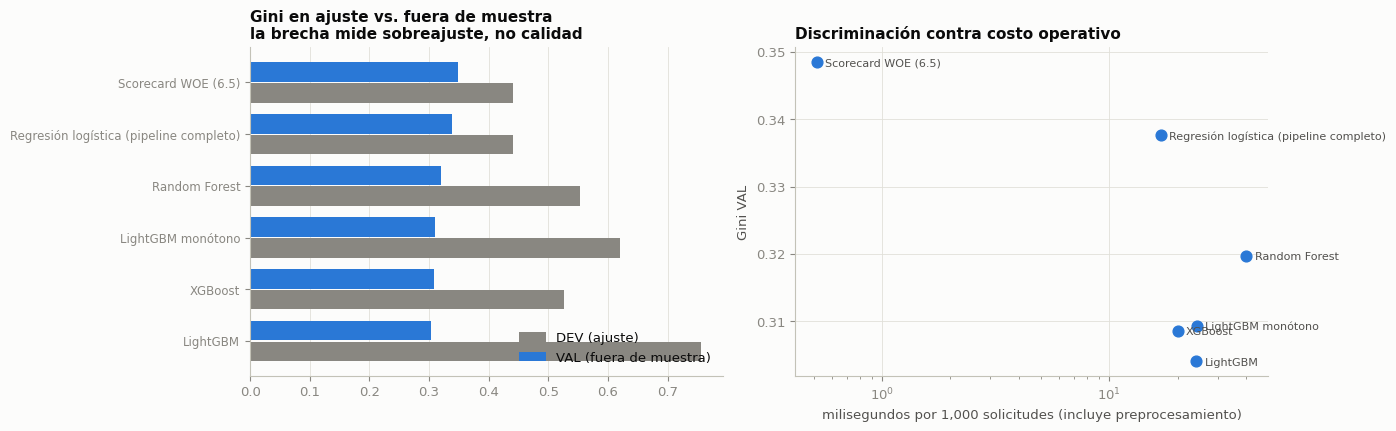

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
orden_plot = comparacion.sort_values("gini_val")
x = np.arange(len(orden_plot))
axes[0].barh(x - 0.2, orden_plot["gini_dev"], height=0.38, color=MUTED, label="DEV (ajuste)")
axes[0].barh(x + 0.2, orden_plot["gini_val"], height=0.38, color=BLUE, label="VAL (fuera de muestra)")
axes[0].set_yticks(x, orden_plot.index, fontsize=8.5)
axes[0].set_title("Gini en ajuste vs. fuera de muestra\nla brecha mide sobreajuste, no calidad")
axes[0].legend(loc="lower right"); axes[0].grid(axis="y", visible=False)
axes[1].scatter(comparacion["latencia_ms_1000"], comparacion["gini_val"], color=BLUE, s=60)
for n, r in comparacion.iterrows():
    axes[1].annotate(n, (r["latencia_ms_1000"], r["gini_val"]), fontsize=8, color=INK_2,
                     xytext=(6, -3), textcoords="offset points")
axes[1].set_xlabel("milisegundos por 1,000 solicitudes (incluye preprocesamiento)")
axes[1].set_ylabel("Gini VAL"); axes[1].set_xscale("log")
axes[1].set_title("Discriminación contra costo operativo")
fig.tight_layout(); savefig(fig, "fig22_modelos_comparacion"); plt.show()

**Lectura.** Tres cosas saltan a la vista:

- **El sobreajuste es enorme en los modelos libres.** LightGBM llega a 0.755 de Gini en DEV y cae a 0.304 en VAL (brecha de 45 puntos); Random Forest, 0.553 contra 0.320. El scorecard tiene la menor brecha (9 puntos) porque tiene tres características en tramos.
- **Fuera de muestra nadie le gana al scorecard.** En VAL: scorecard 0.349, logística con 23 columnas 0.338, Random Forest 0.320, LightGBM monótono 0.309, XGBoost 0.309.
- **Ninguno está calibrado.** Todos subestiman el nivel de 2024 en la misma proporción (observado/predicho entre 1.41 y 1.45): el problema de nivel es del entorno, no del algoritmo, y se corrige en 6.7.

Además, el costo operativo es de otro orden: el scorecard puntúa 1,000 solicitudes en menos de 1 ms y los modelos de árboles necesitan entre 20 y 40 ms, más el artefacto binario y sus dependencias.

## 4. Regla de selección Champion / Challenger

Regla fijada antes de ver los resultados: **gana el modelo más simple cuya discriminación fuera de muestra no sea significativamente peor que la del mejor** (bootstrap pareado sobre VAL, IC 95% de la diferencia de AUC). El mayor AUC no decide por sí solo, como pide el enunciado.

In [6]:
orden_simplicidad = ["Scorecard WOE (6.5)", "Regresión logística (pipeline completo)",
                     "LightGBM monótono", "LightGBM", "XGBoost", "Random Forest"]
seleccion = models.champion_challenger(comparacion, candidatos, val, orden_simplicidad)
print("Mejor Gini en VAL:", seleccion.attrs["mejor_gini_val"])
display(seleccion)
seleccion.to_csv(cfg.TABLES / "modelos_champion_challenger.csv")

Mejor Gini en VAL: Scorecard WOE (6.5)


,simplicidad,gini_val,delta_auc_vs_mejor,ic_inf,ic_sup,peor_de_forma_significativa
modelo,,,,,,
Scorecard WOE (6.5),1,0.3485,0.0000,0.0000,0.0000,False
Regresión logística (pipeline completo),2,0.3377,-0.0054,-0.0284,0.0172,False
LightGBM monótono,3,0.3093,-0.0196,-0.0444,0.0031,False
LightGBM,4,0.3041,-0.0222,-0.0501,0.0023,False
XGBoost,5,0.3086,-0.0199,-0.0405,-0.0004,True
Random Forest,6,0.3198,-0.0144,-0.0318,0.0018,False


**Champion: el scorecard de 6.5. Challenger: LightGBM monótono.**

El scorecard es a la vez el más simple y el de mejor Gini en VAL, así que la regla no necesita arbitrar. Los otros criterios apuntan en la misma dirección: menor brecha DEV-VAL, explicación local exacta por puntos, artefacto JSON auditable y latencia de sub-milisegundo. El challenger es el LightGBM **con restricciones de monotonía**, no el libre: impone la dirección de negocio documentada en 6.5, reduce la brecha de sobreajuste frente a su versión libre y es el candidato natural para volver a competir cuando haya más cosechas.

Lo que hay que vigilar y queda registrado: el challenger puede superar al champion en cosechas donde la relación sea más no lineal, y esa comparación se repite en 6.7 sobre el OOT.

## 5. ¿Cuánto costaría levantar el veto de fairness?

In [7]:
candidatos_libres, _ = models.train_candidates(dev, pipe, card, card.binnings, excluir_sensibles=False)
filas = []
for n in ["Regresión logística (pipeline completo)", "LightGBM monótono", "XGBoost"]:
    filas.append({"modelo": n,
                  "gini_val_con_veto": validation.gini(val[T], candidatos[n].pd_hat(val)),
                  "gini_val_sin_veto": validation.gini(val[T], candidatos_libres[n].pd_hat(val))})
veto = pd.DataFrame(filas).set_index("modelo")
veto["diferencia"] = veto["gini_val_sin_veto"] - veto["gini_val_con_veto"]
display(veto)
veto.to_csv(cfg.TABLES / "modelos_costo_del_veto.csv")

,gini_val_con_veto,gini_val_sin_veto,diferencia
modelo,,,
Regresión logística (pipeline completo),0.3377,0.3299,-0.0077
LightGBM monótono,0.3093,0.3429,0.0336
XGBoost,0.3086,0.3264,0.0178


**Lectura.** Levantar el veto (dejar entrar edad, región, distancia, dependientes y efectivo) mueve el Gini de VAL entre −0.8 y +3.4 puntos según el modelo, y ni siquiera de forma consistente: la logística **empeora**. Es decir, el costo predictivo de la restricción de fairness es pequeño y va en direcciones distintas según el algoritmo, mientras que el costo reputacional y regulatorio de decidir con esas variables es cierto. Aun así, ningún modelo con veto levantado supera al champion en VAL.

## 6. Artefactos y trazabilidad

In [8]:
joblib.dump({"modelo": candidatos["LightGBM monótono"].modelo, "columnas": candidatos["LightGBM monótono"].columnas,
             "params": candidatos["LightGBM monótono"].params, "entrenado_en": "DEV 2021-2023",
             "veto_fairness": vetadas},
            cfg.ROOT / "models" / "challenger_lgbm_v1.joblib")
# El pipeline de preprocesamiento también se persiste: es el artefacto que garantiza que
# entrenamiento y scoring transformen igual (capítulo 7 del enunciado).
joblib.dump({"pipeline": pipe, "columnas_entrada": cols_in, "ajustado_con": "DEV 2021-2023"},
            cfg.ROOT / "models" / "pipeline_preprocesamiento_v1.joblib")
print("Artefactos:", sorted(p.name for p in (cfg.ROOT / "models").glob("*")))

Artefactos: ['calibrador_platt_v1.json', 'challenger_lgbm_v1.joblib', 'ead_lgd_v1.json', 'ficha_ead.md', 'ficha_lgd.md', 'model_card_scorecard_pd.md', 'pipeline_preprocesamiento_v1.joblib', 'politica_decision_v1.json', 'registry.json', 'scorecard_pd_v1.json']


| Requisito 6.6 | Dónde |
|---|---|
| Entrenar logística, Random Forest, XGBoost y LightGBM | §2 y §3 · `src/models.py` |
| Tuning razonable y controlado | §2 · grillas de `models.GRIDS` y validación temporal dentro de DEV |
| Comparar discriminación, calibración, estabilidad, interpretabilidad y complejidad operativa | §3 · `modelos_comparacion.csv` · `fig22` |
| Champion y al menos un Challenger, sin decidir por AUC solo | §4 · regla pre-registrada · `modelos_champion_challenger.csv` |